# Машинное обучение, ФКН ВШЭ

# Практическое задание 2

## Общая информация

### О задании
На сайтах для поиска работы можно найти сотни тысяч объявлений, каждое из которых состоит из пространного описания вакансии и предлагаемой зарплаты. Есть ли связь между описанием и зарплатой? Существуют ли определенные слова, которые наиболее сильно характеризуют зарплату? Можно ли найти другие информативные факторы? Вам предстоит ответить на эти вопросы, проанализировав выборку объявлений о работе в Великобритании.

Практическое задание 2 посвящено работе с текстовыми данными и категориальными признаками и задачам бинарной классификации. Вы научитесь:
 * работать с категориальными признаками;
 * строить вещественные представления текстовых данных;
 * обучать и строить прогнозы линейных классификаторов при помощи scikit-learn;
 * тестировать модели и проводить оценку качества в задачах бинарной классификации.


### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Кроме того, некоторые из заданий являются опциональными (необязательными), однако за их выполнение можно получить дополнительные баллы.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце Вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник). 

Неэффективная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Для сдачи задания переименуйте получившийся файл \*.ipynb в соответствии со следующим форматом: *HW1_Username.ipynb*, где *Username* — Ваша фамилия и инициалы на латинице (например, *HW1_IvanovII.ipynb*). Далее отправьте этот файл на Smorodinov-1990@mail.ru.

## Данные

Как было упомянуто ранее, в рамках данного задания мы будем решать задачу бинарной классификации для предсказания уровня заработной платы по тексту объявления о вакансии на примере набора данных об [аналитиках данных](https://www.kaggle.com/datasets/andrewmvd/data-analyst-jobs).

Посмотрим на данные в файле и загрузим их в DataFrame:

In [21]:
%pylab inline

import pandas as pd

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\Red\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['median']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [22]:
df = pd.read_csv('DataAnalyst.csv', sep=',')
print(df.shape)
df.head()

(2253, 16)


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


Рассмотрим задачу бинарной классификации, разделив объекты на 2 группы: объявления о вакансиях с низкой и высокой зарплатами соответственно.

<img src = "http://salt.uaa.alaska.edu/kath/kti/mean_median2.gif">

В качестве порога разбиения объектов на группы будем рассматривать медиану признака Salary Estimate. Заметим, что таким образом мы автоматически получим задачу классификации со сбалансированными классами:

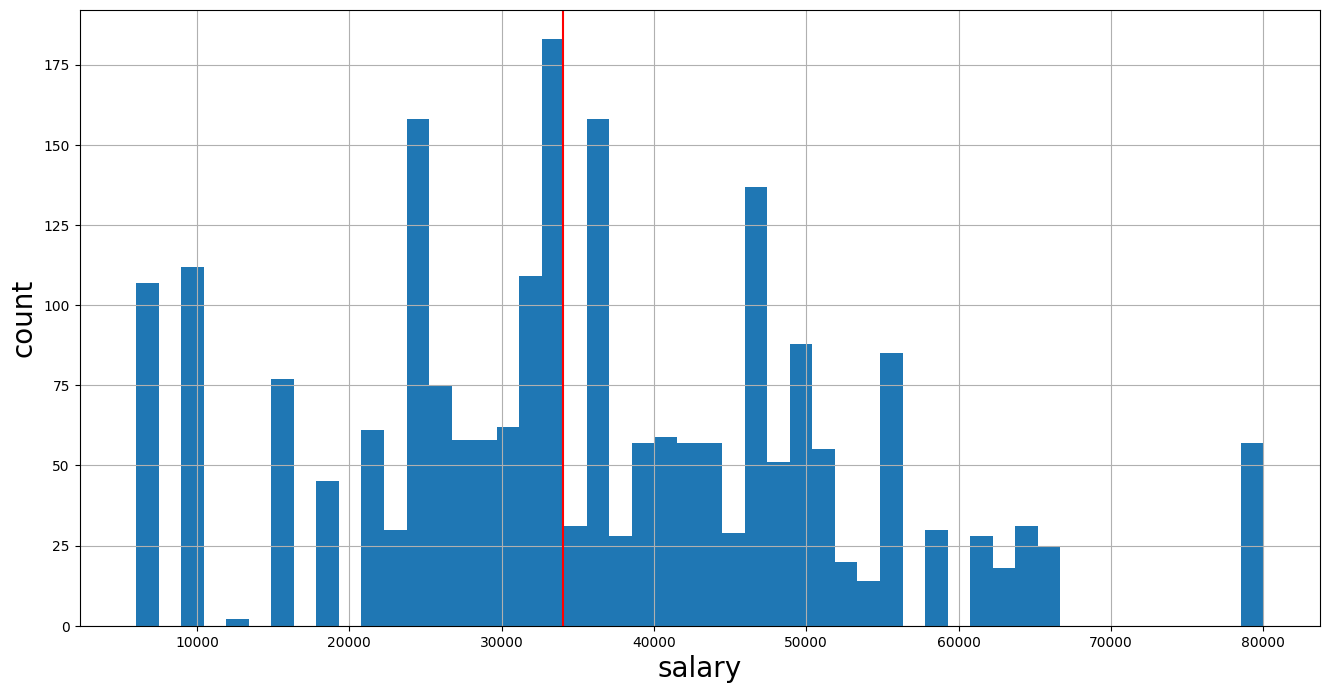

In [23]:
def count_aver_salary(salary):
    salary = salary.split('K-$')
    return (int(salary[1][:salary[1].index('K')]) - int(salary[0][1:])) * 1000

# salary histogramm
df = df[(df['Salary Estimate'] != "-1")]
df['Salary Estimate'] = df['Salary Estimate'].apply(count_aver_salary) 
median = np.median(df['Salary Estimate'])


figsize(16,8)
plt.hist(df['Salary Estimate'], bins=50)
plt.axvline(median, c='r')
plt.xlabel('salary', fontsize=20)
plt.ylabel('count', fontsize=20)
plt.grid()

Осуществим последние шаги по подготовке датасета:
- бинаризуем признак Salary Estimate по описанному ранее порогу.

In [24]:
df['Salary Estimate'] = (df['Salary Estimate'] > median).astype(int)
df.drop('Revenue', axis=1, inplace=True)
df.drop('Easy Apply', axis=1, inplace=True)
df.drop('Rating', axis=1, inplace=True)
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Competitors
0,0,"Data Analyst, Center on Immigration and Justic...",0,Are you eager to roll up your sleeves and harn...,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,-1
1,1,Quality Data Analyst,0,Overview\n\nProvides analytical and technical ...,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",0,We’re looking for a Senior Data Analyst who ha...,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,GoDaddy
3,3,Data Analyst,0,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,-1
4,4,Reporting Data Analyst,0,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",DraftKings


#### 1. (0 баллов) Разбейте получившуюся выборку на обучающую и контрольную в соотношении 70/30 с использованием перемешивания объектов.

При разбиении используйте значение параметра random_state=42.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Salary Estimate', axis=1), 
                                                   df['Salary Estimate'], 
                                                   test_size=0.3, 
                                                   random_state=42)

Размер обучающей выборки: (1576, 12)
Размер контрольной выборки: (676, 12)


## Векторизация

Как правило, модели, используемые в машинном обучении, применяются в предположении, что матрица "объект-признак" является вещественнозначной. Поэтому при работе с категориальными признаками и текстами сперва их необходимо привести к вещественному виду.

Заметим, что в нашей задаче есть признаки, являющиеся текстами произвольной природы (Job Title, Job Description) категориальные признаки, принимающие ограниченное число значений (Headquarters, Industry и др.).

Самый простой и понятный способ преобразования текстовых данных — векторизация. В этом случае для каждого слова, встречающегося в некотором набре текстов мы создаём отдельный новый признак, который будет равен $1$, когда слово встречается в заданном объекте, и $0$ – в противном случае.

#### 2. (0.5 балла) Создайте текстовое описание объектов обучающей и контрольной выборок, объединив значения всех признаков каждого объекта выборки через символы пробела. После этого получите признаковое описание объектов, осуществив векторизацию получившихся текстов при помощи [CountVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html), обучив его на обучающей выборке и применив на контрольной.

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

def combine_features(row):
    return ' '.join(str(val) for val in row)

X_train_text = X_train.apply(combine_features, axis=1)
X_test_text = X_test.apply(combine_features, axis=1)

vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train_text)
X_test_vectorized = vectorizer.transform(X_test_text)

#### 3. (1.5 балла) Обучите модель на обучающей выборке:
 - [логистическую регрессию](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) из модуля sklearn с параметрами по умолчанию.

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_vectorized, y_train)

y_train_pred = model.predict(X_train_vectorized)
y_test_pred = model.predict(X_test_vectorized)

print("Точность на обучающей выборке:", model.score(X_train_vectorized, y_train))
print("Точность на контрольной выборке:", model.score(X_test_vectorized, y_test))

Точность на обучающей выборке: 0.9993654822335025
Точность на контрольной выборке: 0.6331360946745562


#### 4. (0.5 балла) Вычислите значения ROC-AUC, [F-меры](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html), а также постройте [матрицу ошибок](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) для построенной в п. 3 модели на контрольной выборке.

In [34]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

y_test_proba = model.predict_proba(X_test_vectorized)[:, 1]
roc_auc = roc_auc_score(y_test, y_test_proba)

f1 = f1_score(y_test, y_test_pred)

cm = confusion_matrix(y_test, y_test_pred)

print("ROC-AUC:", roc_auc)
print("F-мера:", f1)
print("Матрица ошибок:\n", cm)

ROC-AUC: 0.6817090692458648
F-мера: 0.6172839506172839
Матрица ошибок:
 [[228 120]
 [128 200]]


#### 5. (1 балл) Отсортируйте веса признаков для модели логистической регрессии из scikit-learn, полученной в п. 2. Какие слова из встречающихся в выборке имеют наибольшее/наименьшее влияние на значение целевой переменной? Проинтерпретируйте полученный результат.

In [36]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())

coefs = model.coef_[0]

top_positive_indices = np.argsort(coefs)[-10:][::-1]
top_negative_indices = np.argsort(coefs)[:10]

print("Слова с наибольшим положительным влиянием:")
for idx in top_positive_indices:
    print(f"{feature_names[idx]}: {coefs[idx]:.3f}")

print("\nСлова с наибольшим отрицательным влиянием:")
for idx in top_negative_indices:
    print(f"{feature_names[idx]}: {coefs[idx]:.3f}")

Слова с наибольшим положительным влиянием:
jose: 0.993
az: 0.936
diego: 0.902
san: 0.764
phoenix: 0.743
levels: 0.612
nj: 0.570
ca: 0.563
would: 0.563
what: 0.560

Слова с наибольшим отрицательным влиянием:
antonio: -1.116
chicago: -1.080
il: -1.077
oh: -0.803
fl: -0.721
glendale: -0.624
va: -0.556
bank: -0.537
other: -0.534
combination: -0.524


## TF-IDF

Ещё один способ работы с текстовыми данными — [TF-IDF](https://en.wikipedia.org/wiki/Tf–idf) (**T**erm **F**requency–**I**nverse **D**ocument **F**requency). Рассмотрим коллекцию текстов $D$.  Для каждого уникального слова $t$ из документа $d \in D$ вычислим следующие величины:

1. Term Frequency – количество вхождений слова в отношении к общему числу слов в тексте:
$$\text{tf}(t, d) = \frac{n_{td}}{\sum_{t \in d} n_{td}},$$
где $n_{td}$ — количество вхождений слова $t$ в текст $d$.

2. Inverse Document Frequency
$$\text{idf}(t, D) = \log \frac{\left| D \right|}{\left| \{d\in D: t \in d\} \right|},$$
где $\left| \{d\in D: t \in d\} \right|$ – количество текстов в коллекции, содержащих слово $t$.

Тогда для каждой пары (слово, текст) $(t, d)$ вычислим величину:
$$\text{tf-idf}(t,d, D) = \text{tf}(t, d)\cdot \text{idf}(t, D).$$

Отметим, что значение $\text{tf}(t, d)$ корректируется для часто встречающихся общеупотребимых слов при помощи значения $\text{idf}(t, D).$

Признаковым описанием одного объекта $d \in D$ будет вектор $\bigg(\text{tf-idf}(t,d, D)\bigg)_{t\in V}$, где $V$ – словарь всех слов, встречающихся в коллекции $D$.

#### 6. (0.5 балла) Создайте текстовое описание объектов обучающей и контрольной выборок, объединив значения всех признаков каждого объекта выборки через символы пробела. После этого получите признаковое описание объектов, вычислив вектор tf-idf для каждого объекта помощи [TfidfVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), обучив его на обучающей выборке и применив на контрольной.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

#### 7. (0 баллов) Обучите следующую модель на обучающей выборке:
- [логистическую регрессию](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) из модуля sklearn с параметрами по умолчанию.

In [40]:
model_tfidf = LogisticRegression(random_state=42, max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

y_train_pred_tfidf = model_tfidf.predict(X_train_tfidf)
y_test_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("Точность на обучающей выборке (tf-idf):", model_tfidf.score(X_train_tfidf, y_train))
print("Точность на контрольной выборке (tf-idf):", model_tfidf.score(X_test_tfidf, y_test))

Точность на обучающей выборке (tf-idf): 0.9035532994923858
Точность на контрольной выборке (tf-idf): 0.6538461538461539


#### 8. (0.5 балла) Вычислите значения ROC-AUC, [F-меры](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html), а также постройте [матрицу ошибок](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) для построенной в п. 7 модели на контрольной выборке.

In [41]:
y_test_proba_tfidf = model_tfidf.predict_proba(X_test_tfidf)[:, 1]

roc_auc_tfidf = roc_auc_score(y_test, y_test_proba_tfidf)

f1_tfidf = f1_score(y_test, y_test_pred_tfidf)

cm_tfidf = confusion_matrix(y_test, y_test_pred_tfidf)

print("ROC-AUC (tf-idf):", roc_auc_tfidf)
print("F-мера (tf-idf):", f1_tfidf)
print("Матрица ошибок (tf-idf):\n", cm_tfidf)

ROC-AUC (tf-idf): 0.7090254415475189
F-мера (tf-idf): 0.6475903614457831
Матрица ошибок (tf-idf):
 [[227 121]
 [113 215]]


#### 9. (0.5 балла) Сравните значения метрик из п. 8 со значениями, полученными в п. 5, и сравните соответствующие модели по качеству из работы.

**Ответ**: 
модель Tfidf показало немного лучшие результаты:  

ROC-AUC **0.6817090692458648 к 0.7090254415475189**  

F-мера **0.6172839506172839 к 0.6475903614457831**  

Матрица ошибок:  
 [[228 120]  
 [128 200]]  

 к  
 
  [[227 121]  
 [113 215]]

#### 10. (1 балл) Отсортируйте веса признаков для модели логистической регрессии из scikit-learn, полученной в п. 7. Какие слова из встречающихся в выборке имеют наибольшее/наименьшее влияние на значение целевой переменной? Проинтерпретирйте полученный результат.

In [42]:
tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

tfidf_coefs = model_tfidf.coef_[0]

top_positive_indices = np.argsort(tfidf_coefs)[-10:][::-1]
top_negative_indices = np.argsort(tfidf_coefs)[:10]

print("Слова с наибольшим положительным влиянием:")
for idx in top_positive_indices:
    print(f"{tfidf_feature_names[idx]}: {tfidf_coefs[idx]:.3f}")

print("\nСлова с наибольшим отрицательным влиянием:")
for idx in top_negative_indices:
    print(f"{tfidf_feature_names[idx]}: {tfidf_coefs[idx]:.3f}")

Слова с наибольшим положительным влиянием:
ca: 1.888
az: 1.633
san: 1.590
diego: 1.330
jose: 1.225
phoenix: 1.211
francisco: 1.073
teams: 1.011
charlotte: 0.940
maintenance: 0.802

Слова с наибольшим отрицательным влиянием:
chicago: -2.496
il: -2.289
antonio: -1.381
bank: -1.017
oh: -0.894
houston: -0.825
sas: -0.771
ut: -0.741
analytics: -0.730
preferred: -0.727


## Счётчики

Ранее в рамках данного задания при построении моделей мы объединяли значения всех признаков в единую строку, что предполагает равноправность всех признаков. Однако заметим, что в этом случае мы допускаем потерю информации: слово "New York" может по-разному влиять на зарплату, если оно находится в названии объявления и в геолокации. Чтобы устранить этот недостаток, при создании текстового описания объекта будем объединять только значения признаков Job Title и Job Description, а остальные будем рассматривать как категориальные. При этом с полученным текстовым описанием объекта будем работать, как раньше (при помощи векторизации или tf-idf), а для кодирования категориальных признаков используем **счётчики**.

Идея этого метода состоит в том, чтобы заменить значение категориального признака на вероятность того, что объект с данным значением признака относится к положительному классу. Опишем эту идею более формально. Пусть у нас есть выборка $X = \{ (x_i, y_i) \}_{i=1}^l,$ и $j$-ый признак принимает значения из множества $U_j = \{ u_{jn}\}_{n=1}^{N_j},$ где $N_j$ — количество различных значений $j$-ого признака. Пусть $x_{ij} = u_{jn},$ тогда заменим значения $j$-ого категориального признака объекта $x_i$ на следующую оценку: 
$$\hat{P}(y_i=+1|x_{ij}=u_{jn}) = \frac{\sum_{m=1}^l \left[ x_{mj} = u_{jn} \right] \left[ y_m = +1 \right]}{\sum_{m=1}^l \left[ x_{mj} = u_{jn} \right]}.$$

Однако заметим, что при таком способе формирования счётчиков мы учитываем в формуле для объекта $x_i$ его метку $y_i$, тем самым вносим информацию об ответе в признаки. Чтобы устранить этот недостаток, при вычислении счётчика будем исключать из рассмотрения текущий объект, т.е. рассматривать следующую оценку:
$$\hat{P}(y_i=+1|X_{ij}=u_{jn}) = \frac{\sum_{m=1, \\ m \ne i}^l \left[ x_{mj} = u_{jn} \right] \left[ y_m = +1 \right]}{\sum_{m=1, \\ m \ne i}^l \left[ x_{mj} = u_{jn} \right]},$$

#### 11. (0.5 балла) Создайте текстовое описание объектов обучающей и контрольной выборок, объединив значения признаков Job Title и Job Description каждого объекта выборки через символ пробела, после чего перейдите к признаковому описанию объектов, вычислив вектор tf-idf аналогично п. 6.

In [45]:
X_train_text2 = X_train['Job Title'].astype(str) + ' ' + X_train['Job Description'].astype(str)
X_test_text2 = X_test['Job Title'].astype(str) + ' ' + X_test['Job Description'].astype(str)

tfidf_vectorizer2 = TfidfVectorizer()
X_train_tfidf2 = tfidf_vectorizer2.fit_transform(X_train_text2)
X_test_tfidf2 = tfidf_vectorizer2.transform(X_test_text2)

#### 12. (1 балл) Закодируйте категориальные признаки (все, кроме Job Title и Job Description) при помощи [one-hot encoding](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html), после чего обучите логистическую регрессию на обучающей выборке. Вычислите значения ROC-AUC, [F-меры](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html), а также постройте [матрицу ошибок](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) для полученной модели на контрольной выборке. 

In [47]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix

cat_features = [col for col in X_train.columns if col not in ['Job Title', 'Job Description']]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_cat = ohe.fit_transform(X_train[cat_features])
X_test_cat = ohe.transform(X_test[cat_features])

X_train_full = hstack([X_train_tfidf2, X_train_cat])
X_test_full = hstack([X_test_tfidf2, X_test_cat])

model_full = LogisticRegression(random_state=42, max_iter=1000)
model_full.fit(X_train_full, y_train)

y_test_pred_full = model_full.predict(X_test_full)
y_test_proba_full = model_full.predict_proba(X_test_full)[:, 1]

roc_auc_full = roc_auc_score(y_test, y_test_proba_full)
f1_full = f1_score(y_test, y_test_pred_full)
cm_full = confusion_matrix(y_test, y_test_pred_full)

print("ROC-AUC:", roc_auc_full)
print("F-мера:", f1_full)
print("Матрица ошибок:\n", cm_full)

ROC-AUC: 0.7782099803756658
F-мера: 0.7111111111111111
Матрица ошибок:
 [[241 107]
 [ 88 240]]


#### 13. (2 балла) Для выборки, полученной в п. 11, закодируйте категориальные признаки (все, кроме Job Title и Job Description) при помощи счётчиков, после чего обучите логистическую регрессию на обучающей выборке. Вычислите значения ROC-AUC, [F-меры](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html), а также постройте [матрицу ошибок](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) для полученной модели на контрольной выборке. 

Уделите внимание оптимальности вычисления счётчиков!

In [ ]:
def target_encode(train, test, y_train, cols):
    train_encoded = train.copy()
    test_encoded = test.copy()
    for col in cols:
        
        means = train.groupby(col)[y_train.name].mean()
        counts = train.groupby(col)[y_train.name].count()
       
        train_encoded[col + '_te'] = [
            (means[val] * counts[val] - y) / (counts[val] - 1) if counts[val] > 1 else means[val]
            for val, y in zip(train[col], y_train)
        ]
        test_encoded[col + '_te'] = test[col].map(means)
        test_encoded[col + '_te'] = test_encoded[col + '_te'].fillna(y_train.mean())

    return train_encoded[[c for c in train_encoded.columns if c.endswith('_te')]], \
           test_encoded[[c for c in test_encoded.columns if c.endswith('_te')]]

cat_features = [col for col in X_train.columns if col not in ['Job Title', 'Job Description']]

y_train_named = y_train.copy()
y_train_named.name = 'target'

X_train_cat = X_train[cat_features].fillna('__nan__').copy()
X_test_cat = X_test[cat_features].fillna('__nan__').copy()
X_train_cat['target'] = y_train_named


X_train_te, X_test_te = target_encode(X_train_cat, X_test[cat_features], y_train_named, cat_features)

X_train_full_te = hstack([X_train_tfidf2, csr_matrix(X_train_te.values)])
X_test_full_te = hstack([X_test_tfidf2, csr_matrix(X_test_te.values)])

model_te = LogisticRegression(random_state=42, max_iter=1000)
model_te.fit(X_train_full_te, y_train)

y_test_pred_te = model_te.predict(X_test_full_te)
y_test_proba_te = model_te.predict_proba(X_test_full_te)[:, 1]

roc_auc_te = roc_auc_score(y_test, y_test_proba_te)
f1_te = f1_score(y_test, y_test_pred_te)
cm_te = confusion_matrix(y_test, y_test_pred_te)

print("ROC-AUC (target encoding):", roc_auc_te)
print("F-мера (target encoding):", f1_te)
print("Матрица ошибок (target encoding):\n", cm_te)

ROC-AUC (target encoding): 0.7338975329408467
F-мера (target encoding): 0.6614906832298136
Матрица ошибок (target encoding):
 [[245 103]
 [115 213]]


#### 14. (0.5 балла) Сравните значения метрик из п. 13 со значениями, полученными в п. 12, и сделайте вывод о качестве классификации для каждого из методов кодирования категориальных признаков.

**Ответ:** почему-то получилось хуже 3(
    

## Подбор гиперпараметров

#### 15. (1.5 доп. балла) Разбейте обучающую выборку, полученную в п. 11, на обучающую и валидационную в отношении 80/20, после чего подберите оптимальное количество фолдов, используемое при кодировании категориальных признаков (всех, кроме Job Title и Job Description), путём оптимизации значения accuracy на валидационной выборке. Используйте следующую модель, аналогично также подобрав оптимальные значения указанных гиперпараметров:
- логистическую регрессию из модуля sklearn с подбором коэффициента регуляризации.

In [53]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
X_tr_text, X_val_text, X_tr_cat, X_val_cat, y_tr, y_val = train_test_split(
    X_train_text2, X_train[cat_features], y_train, test_size=0.2, random_state=42, stratify=y_train
)

tfidf_vectorizer_cv = TfidfVectorizer()
X_tr_tfidf = tfidf_vectorizer_cv.fit_transform(X_tr_text)
X_val_tfidf = tfidf_vectorizer_cv.transform(X_val_text)


def kfold_target_encode(X, y, X_val, cols, n_folds=5, random_state=42):
    X = X.copy()
    X_val = X_val.copy()
    y = y.reset_index(drop=True)
    X_te = pd.DataFrame(index=X.index)
    X_val_te = pd.DataFrame(index=X_val.index)
    global_mean = y.mean()
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    for col in cols:
        X_te_col = pd.Series(index=X.index, dtype=float)
        for train_idx, val_idx in kf.split(X):

            X_fold = X.iloc[train_idx].copy()
            X_fold['target'] = y.iloc[train_idx].values
            means = X_fold.groupby(col)['target'].mean()
            X_te_col.iloc[val_idx] = X.iloc[val_idx][col].map(means)
        X_te_col.fillna(global_mean, inplace=True)
        X_te[col + '_te'] = X_te_col

        X_all = X.copy()
        X_all['target'] = y.values
        means = X_all.groupby(col)['target'].mean()
        X_val_te[col + '_te'] = X_val[col].map(means)
        X_val_te[col + '_te'] = X_val_te[col + '_te'].fillna(global_mean)
    return X_te, X_val_te

best_acc = 0
best_params = None

folds_grid = [3, 5, 7, 10]
C_grid = [0.01, 0.1, 1, 10, 100]

for n_folds in folds_grid:
    X_tr_te, X_val_te = kfold_target_encode(X_tr_cat.fillna('__nan__'), y_tr, X_val_cat.fillna('__nan__'), cat_features, n_folds=n_folds)

    X_tr_full = hstack([X_tr_tfidf, csr_matrix(X_tr_te.values)])
    X_val_full = hstack([X_val_tfidf, csr_matrix(X_val_te.values)])
    for C in C_grid:
        model = LogisticRegression(random_state=42, max_iter=1000, C=C)
        model.fit(X_tr_full, y_tr)
        y_val_pred = model.predict(X_val_full)
        acc = accuracy_score(y_val, y_val_pred)
        if acc > best_acc:
            best_acc = acc
            best_params = (n_folds, C)
        print(f"n_folds={n_folds}, C={C}, accuracy={acc:.4f}")

print(f"\nЛучшие параметры: n_folds={best_params[0]}, C={best_params[1]}, accuracy={best_acc:.4f}")

n_folds=3, C=0.01, accuracy=0.6582
n_folds=3, C=0.1, accuracy=0.6424
n_folds=3, C=1, accuracy=0.6361
n_folds=3, C=10, accuracy=0.6741
n_folds=3, C=100, accuracy=0.6424
n_folds=5, C=0.01, accuracy=0.6646
n_folds=5, C=0.1, accuracy=0.6487
n_folds=5, C=1, accuracy=0.6297
n_folds=5, C=10, accuracy=0.6677
n_folds=5, C=100, accuracy=0.6582
n_folds=7, C=0.01, accuracy=0.6582
n_folds=7, C=0.1, accuracy=0.6519
n_folds=7, C=1, accuracy=0.6361
n_folds=7, C=10, accuracy=0.6677
n_folds=7, C=100, accuracy=0.6487
n_folds=10, C=0.01, accuracy=0.6614
n_folds=10, C=0.1, accuracy=0.6487
n_folds=10, C=1, accuracy=0.6361
n_folds=10, C=10, accuracy=0.6709
n_folds=10, C=100, accuracy=0.6677

Лучшие параметры: n_folds=3, C=10, accuracy=0.6741


#### 16. (0.5 доп. балла) Обучите указанные выше модели на обучающей выборке для оптимальных значений гиперпараметров, найденных в п. 15, после чего для каждой из моделей вычислите значения ROC-AUC, F-меры, а также постройте матрицу ошибок на контрольной выборке. Как качество классификации при помощи полученной в данном разделе модели соотносится с моделями, полученными в предыдущих разделах?

In [56]:
best_n_folds, best_C = best_params

X_train_te, X_test_te = kfold_target_encode(
    X_train[cat_features].fillna('__nan__'), y_train, X_test[cat_features].fillna('__nan__'),
    cat_features, n_folds=best_n_folds
)

tfidf_vectorizer_final = TfidfVectorizer()
X_train_tfidf_final = tfidf_vectorizer_final.fit_transform(X_train_text2)
X_test_tfidf_final = tfidf_vectorizer_final.transform(X_test_text2)

X_train_full_final = hstack([X_train_tfidf_final, csr_matrix(X_train_te.values)])
X_test_full_final = hstack([X_test_tfidf_final, csr_matrix(X_test_te.values)])

model_final = LogisticRegression(random_state=42, max_iter=1000, C=best_C)
model_final.fit(X_train_full_final, y_train)

y_test_pred_final = model_final.predict(X_test_full_final)
y_test_proba_final = model_final.predict_proba(X_test_full_final)[:, 1]

roc_auc_final = roc_auc_score(y_test, y_test_proba_final)
f1_final = f1_score(y_test, y_test_pred_final)
cm_final = confusion_matrix(y_test, y_test_pred_final)

print("ROC-AUC:", roc_auc_final)
print("F-мера:", f1_final)
print("Матрица ошибок:\n", cm_final)

ROC-AUC: 0.770132464255677
F-мера: 0.6895522388059702
Матрица ошибок:
 [[237 111]
 [ 97 231]]


Здесь вы можете поделиться своими мыслями по поводу этого задания.

А здесь — вставить вашу вторую любимую смешную картинку.

![мой любимый мем](okak-8.png)

А здесь — посоветовать преподавателям хороший фильм или сериал.

Реквием по мечте, самый достойный фильм